In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

print("Libraries imported successfully!")

Libraries imported successfully!


In [7]:
import requests
import zipfile

url = "https://files.grouplens.org/datasets/movielens/ml-latest-small.zip"
zip_path = "../data/movielens.zip"

response = requests.get(url, verify=False)
response.raise_for_status()

with open(zip_path, "wb") as file:
    file.write(response.content)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("../data/")

print("MovieLens dataset downloaded successfully!")

d:\movie-match\venv\Lib\site-packages\urllib3\connectionpool.py:1129: InsecureRequestWarning: Unverified HTTPS request is being made to host 'files.grouplens.org'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


MovieLens dataset downloaded successfully!


In [8]:
# Load movies dataset
movies = pd.read_csv("../data/ml-latest-small/movies.csv")

# Display first 5 rows
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [9]:
print("Total movies:", len(movies))
print("Columns:", movies.columns.tolist())

Total movies: 9742
Columns: ['movieId', 'title', 'genres']


In [10]:
# Count movies by genre
genre_counts = {}

for genres in movies["genres"]:
    for genre in genres.split("|"):
        if genre != "(no genres listed)":
            genre_counts[genre] = genre_counts.get(genre, 0) + 1

genre_distribution = pd.DataFrame(
    list(genre_counts.items()),
    columns=["Genre", "Movie Count"]
).sort_values(
    by="Movie Count",
    ascending=False
)

genre_distribution

,Genre,Movie Count
6,Drama,4361
3,Comedy,3756
9,Thriller,1894
7,Action,1828
5,Romance,1596
0,Adventure,1263
8,Crime,1199
12,Sci-Fi,980
10,Horror,978
4,Fantasy,779


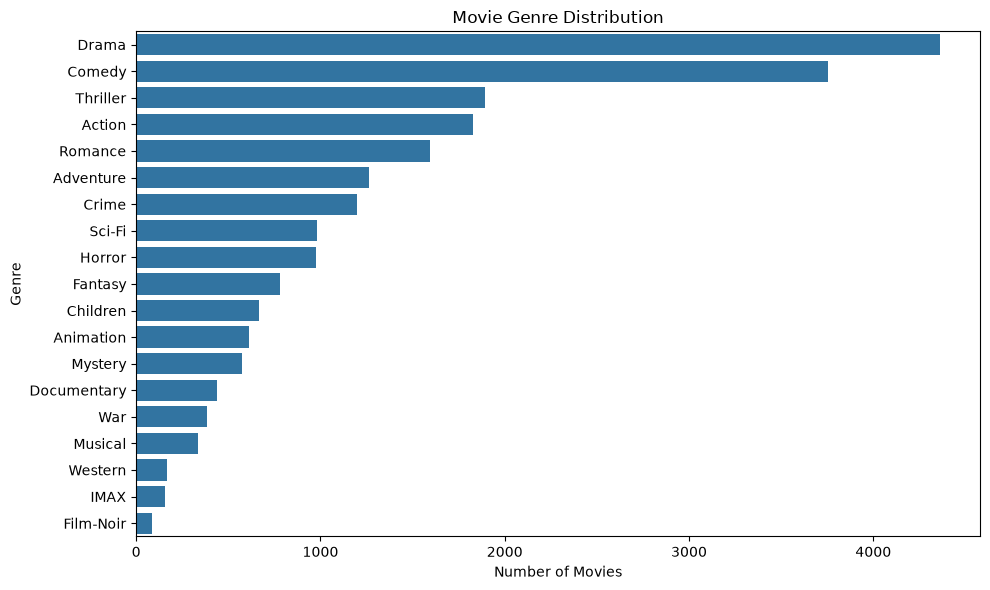

In [11]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=genre_distribution,
    x="Movie Count",
    y="Genre"
)

plt.title("Movie Genre Distribution")
plt.xlabel("Number of Movies")
plt.ylabel("Genre")
plt.tight_layout()

plt.savefig("../images/genre_distribution.png")
plt.show()

In [12]:
# Load ratings dataset
ratings = pd.read_csv("../data/ml-latest-small/ratings.csv")

# Display first 5 rows
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [13]:
print("Total ratings:", len(ratings))
print("Total users:", ratings["userId"].nunique())
print("Average rating:", ratings["rating"].mean())

Total ratings: 100836
Total users: 610
Average rating: 3.501556983616962


In [14]:
# Create a combined feature column
movies["features"] = movies["title"] + " " + movies["genres"].str.replace("|", " ")

# Display the updated dataset
movies[["title", "genres", "features"]].head()

,title,genres,features
0,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,Toy Story (1995) Adventure Animation Children ...
1,Jumanji (1995),Adventure|Children|Fantasy,Jumanji (1995) Adventure Children Fantasy
2,Grumpier Old Men (1995),Comedy|Romance,Grumpier Old Men (1995) Comedy Romance
3,Waiting to Exhale (1995),Comedy|Drama|Romance,Waiting to Exhale (1995) Comedy Drama Romance
4,Father of the Bride Part II (1995),Comedy,Father of the Bride Part II (1995) Comedy


In [15]:
# Create TF-IDF vectorizer
tfidf = TfidfVectorizer(
    stop_words="english"
)

# Convert movie features into numerical vectors
tfidf_matrix = tfidf.fit_transform(movies["features"])

print("TF-IDF matrix shape:", tfidf_matrix.shape)
print("TF-IDF vectorization completed successfully!")

TF-IDF matrix shape: (9742, 9060)
TF-IDF vectorization completed successfully!


In [16]:
# Calculate cosine similarity between movies
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

print("Cosine similarity matrix shape:", cosine_sim.shape)
print("Cosine similarity calculated successfully!")

Cosine similarity matrix shape: (9742, 9742)
Cosine similarity calculated successfully!


In [17]:
def recommend_movies(movie_title, num_recommendations=5):
    # Find the movie index
    matching_movies = movies[
        movies["title"].str.lower() == movie_title.lower()
    ]

    if matching_movies.empty:
        return "Movie not found!"

    movie_index = matching_movies.index[0]

    # Get similarity scores
    similarity_scores = list(
        enumerate(cosine_sim[movie_index])
    )

    # Sort by similarity (highest first)
    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    # Select similar movies (exclude the input movie)
    similar_movie_indices = [
        index for index, score in similarity_scores[1:num_recommendations + 1]
    ]

    # Return recommended movies
    return movies.iloc[similar_movie_indices][
        ["title", "genres"]
    ]

In [18]:
# Display some movie titles
movies["title"].head(10)

0                      Toy Story (1995)
1                        Jumanji (1995)
2               Grumpier Old Men (1995)
3              Waiting to Exhale (1995)
4    Father of the Bride Part II (1995)
5                           Heat (1995)
6                        Sabrina (1995)
7                   Tom and Huck (1995)
8                   Sudden Death (1995)
9                      GoldenEye (1995)
Name: title, dtype: str

In [19]:
recommend_movies("Toy Story (1995)", 5)

,title,genres
2355,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy
7355,Toy Story 3 (2010),Adventure|Animation|Children|Comedy|Fantasy|IMAX
3595,"Toy, The (1982)",Comedy
2539,We're Back! A Dinosaur's Story (1993),Adventure|Animation|Children|Fantasy
26,Now and Then (1995),Children|Drama


In [20]:
# Calculate rating statistics for each movie
rating_stats = ratings.groupby("movieId").agg(
    average_rating=("rating", "mean"),
    rating_count=("rating", "count")
).reset_index()

# Merge ratings with movie data
movies_with_ratings = movies.merge(
    rating_stats,
    on="movieId",
    how="left"
)

# Fill missing values
movies_with_ratings["average_rating"] = (
    movies_with_ratings["average_rating"].fillna(0)
)

movies_with_ratings["rating_count"] = (
    movies_with_ratings["rating_count"].fillna(0)
)

movies_with_ratings[
    ["title", "average_rating", "rating_count"]
].head()

,title,average_rating,rating_count
0,Toy Story (1995),3.920930,215.0
1,Jumanji (1995),3.431818,110.0
2,Grumpier Old Men (1995),3.259615,52.0
3,Waiting to Exhale (1995),2.357143,7.0
4,Father of the Bride Part II (1995),3.071429,49.0


In [21]:
# Calculate popularity score
movies_with_ratings["popularity_score"] = (
    movies_with_ratings["average_rating"] *
    np.log1p(movies_with_ratings["rating_count"])
)

# Sort movies by popularity
popular_movies = movies_with_ratings.sort_values(
    by="popularity_score",
    ascending=False
)

popular_movies[
    ["title", "average_rating", "rating_count", "popularity_score"]
].head(10)

,title,average_rating,rating_count,popularity_score
277,"Shawshank Redemption, The (1994)",4.429022,317.0,25.520253
314,Forrest Gump (1994),4.164134,329.0,24.148197
257,Pulp Fiction (1994),4.197068,307.0,24.049621
1939,"Matrix, The (1999)",4.192446,278.0,23.608552
510,"Silence of the Lambs, The (1991)",4.161290,279.0,23.447995
224,Star Wars: Episode IV - A New Hope (1977),4.231076,251.0,23.395433
2226,Fight Club (1999),4.272936,218.0,23.027157
461,Schindler's List (1993),4.225000,220.0,22.807237
898,Star Wars: Episode V - The Empire Strikes Back...,4.215640,211.0,22.581438
659,"Godfather, The (1972)",4.289062,192.0,22.572007


In [22]:
def hybrid_recommend_movies(movie_title, num_recommendations=5):
    matching_movies = movies[
        movies["title"].str.lower() == movie_title.lower()
    ]

    if matching_movies.empty:
        return "Movie not found!"

    movie_index = matching_movies.index[0]

    # Get similarity scores
    similarity_scores = list(
        enumerate(cosine_sim[movie_index])
    )

    recommendations = []

    for index, similarity in similarity_scores:
        if index == movie_index:
            continue

        movie = movies_with_ratings.iloc[index]

        # Normalize popularity
        popularity = movie["popularity_score"]

        # Hybrid score
        hybrid_score = (
            0.7 * similarity +
            0.3 * (popularity / popular_movies["popularity_score"].max())
        )

        recommendations.append({
            "title": movie["title"],
            "genres": movie["genres"],
            "similarity_score": similarity,
            "average_rating": movie["average_rating"],
            "hybrid_score": hybrid_score
        })

    recommendations_df = pd.DataFrame(recommendations)

    return recommendations_df.sort_values(
        by="hybrid_score",
        ascending=False
    ).head(num_recommendations)

In [23]:
hybrid_recommend_movies("Toy Story (1995)", 10)

,title,genres,similarity_score,average_rating,hybrid_score
2354,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy,0.880446,3.860825,0.824403
7354,Toy Story 3 (2010),Adventure|Animation|Children|Comedy|Fantasy|IMAX,0.821047,4.109091,0.769173
7038,Up (2009),Adventure|Animation|Children|Drama,0.353342,4.004762,0.466883
3567,"Monsters, Inc. (2001)",Adventure|Animation|Children|Comedy|Fantasy,0.344687,3.871212,0.463829
3193,Shrek (2001),Adventure|Animation|Children|Comedy|Fantasy|Ro...,0.322302,3.867647,0.459380
0,Jumanji (1995),Adventure|Children|Fantasy,0.357970,3.431818,0.440573
1616,"NeverEnding Story, The (1984)",Adventure|Children|Fantasy,0.385685,3.581395,0.429296
2109,"Christmas Story, A (1983)",Children|Comedy,0.341791,3.972727,0.427241
3594,"Toy, The (1982)",Comedy,0.538018,2.375000,0.421546
8899,Inside Out (2015),Adventure|Animation|Children|Comedy|Drama|Fantasy,0.334174,3.813953,0.403584


In [24]:
import pickle
import os

# Save TF-IDF vectorizer
with open("../models/tfidf_vectorizer.pkl", "wb") as file:
    pickle.dump(tfidf, file)

# Save TF-IDF matrix
with open("../models/tfidf_matrix.pkl", "wb") as file:
    pickle.dump(tfidf_matrix, file)

# Save movie data
movies_with_ratings.to_csv(
    "../models/movies_with_ratings.csv",
    index=False
)

print("Recommendation model files saved successfully!")

Recommendation model files saved successfully!
